# 2. Training ResNet18 with PyTorch (GPU Accelerated)

2-stage training:
1. Frozen backbone: 5 epochs (learn custom head)
2. Fine-tuning: 20 epochs (fine-tune entire network)

In [3]:
# ============================================================================
# 2_Training_ResNet18.ipynb - Train ResNet18 Model with GPU Acceleration
# ============================================================================
# Purpose: 2-stage training untuk river turbidity classification
#   Stage 1 (5 epochs): Frozen backbone, train custom head only
#   Stage 2 (20 epochs): Fine-tune entire network untuk better accuracy
# 
# Hardware: RTX 4070 Super (12GB VRAM) dengan CUDA 11.8
# ============================================================================

# Import PyTorch libraries
import torch
import torch.nn as nn                                   # Neural network modules
import torch.optim as optim                             # Optimizers (Adam, SGD, etc)
from torch.utils.data import TensorDataset, DataLoader  # Data handling
from torchvision import models                          # Pre-trained models (ResNet, etc)

# Import utilities
import numpy as np
from pathlib import Path
import json
from datetime import datetime
import matplotlib.pyplot as plt

# ============================================================================
# Check GPU Availability
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")  # Show GPU name
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")  # Show total VRAM

Device: cuda
GPU: NVIDIA GeForce RTX 4070 SUPER
VRAM: 12.88 GB


## 1. Load Preprocessed Data

In [4]:
# ============================================================================
# Step 1: Load Data from datasetScrap3_augmented
# ============================================================================
# Menggunakan dataset yang sama dengan XceptionNet training
# Dataset: datasetScrap3_augmented (1000 images: 500 jernih + 500 keruh)
# Split: 70% train (700), 15% validation (150), 15% test (150)

import os
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

# Dataset paths
dataset_root = "F:\\TA1\\datasetScrap3_augmented"

# Verify dataset exists
assert os.path.exists(dataset_root), f"Dataset not found at {dataset_root}"

# Count images
jernih_count = len([f for f in os.listdir(os.path.join(dataset_root, 'jernih')) 
                    if f.lower().endswith(('.jpg', '.png', '.jpeg'))])
keruh_count = len([f for f in os.listdir(os.path.join(dataset_root, 'keruh')) 
                   if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

print(f"📊 Dataset Summary:")
print(f"   Jernih (Clear): {jernih_count} images")
print(f"   Keruh (Turbid): {keruh_count} images")
print(f"   Total: {jernih_count + keruh_count} images")
print(f"   Location: {dataset_root}")

# Data transformations untuk training
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Data transformations untuk validation & test
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Load full dataset
full_dataset = ImageFolder(dataset_root, transform=train_transforms)

# Split into train/val/test (70/15/15)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)   # 700
val_size = int(0.15 * total_size)    # 150
test_size = total_size - train_size - val_size  # 150

from torch.utils.data import random_split
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Override val & test dataset transform untuk consistency
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

print(f"\n📈 Train/Val/Test Split (70/15/15):")
print(f"   Training: {train_size} images")
print(f"   Validation: {val_size} images")
print(f"   Test: {test_size} images")

📊 Dataset Summary:
   Jernih (Clear): 500 images
   Keruh (Turbid): 500 images
   Total: 1000 images
   Location: F:\TA1\datasetScrap3_augmented

📈 Train/Val/Test Split (70/15/15):
   Training: 700 images
   Validation: 150 images
   Test: 150 images


## 2. ImageNet Normalization & Create Data Loaders

In [5]:
# ============================================================================
# Step 2: Create Data Loaders
# ============================================================================
# Hyperparameters
BATCH_SIZE = 32
NUM_WORKERS = 4
SHUFFLE = True

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=SHUFFLE,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"✅ Data loaders created:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ Data loaders created:
   Batch size: 32
   Training batches: 22
   Validation batches: 5
   Test batches: 5


## 3. Build ResNet18 Model

In [6]:
# ============================================================================
# Step 3: Build ResNet18 Model Architecture
# ============================================================================
# ResNet18 adalah convolutional neural network dengan 18 layers
# Pre-trained pada ImageNet dataset (1.2 million images, 1000 classes)
# 
# WHY ResNet18?
#   - Lightweight (11.2M parameters vs Xception 20.9M) → less overfitting
#   - Fast training (~15-30 min) vs heavy models
#   - High accuracy untuk binary classification

# Load pre-trained ResNet18 weights dari ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Modify final layer untuk binary classification (Clear vs Turbid)
# ResNet18 default final layer: Linear(512, 1000) untuk 1000 ImageNet classes
# Kita replace dengan custom head untuk 2 classes

num_features = model.fc.in_features  # 512 features dari ResNet18 backbone

# Custom classification head
model.fc = nn.Sequential(
    nn.Linear(num_features, 256),        # 512 → 256 (reduce dimensionality)
    nn.ReLU(inplace=True),               # Activation function
    nn.Dropout(0.5),                     # Regularization (drop 50% of neurons)
    nn.Linear(256, 2)                    # 256 → 2 (final classification)
)

# Move model ke GPU
model = model.to(device)

# Print model information
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters (after freezing): {trainable_params:,}")

Total parameters: 11,308,354
Trainable parameters (after freezing): 11,308,354


In [7]:
# ============================================================================
# Step 4: Define Training & Validation Functions
# ============================================================================

def train_epoch(model, loader, criterion, optimizer, device):
    """
    Train untuk 1 epoch
    
    Args:
        model: PyTorch model
        loader: DataLoader dengan training batches
        criterion: Loss function (CrossEntropyLoss)
        optimizer: Optimizer (Adam)
        device: 'cuda' atau 'cpu'
    
    Returns:
        avg_loss: Average loss untuk epoch ini
        accuracy: Training accuracy untuk epoch ini
    """
    model.train()  # Set model ke training mode (enable dropout, etc)
    total_loss = 0
    correct = 0
    total = 0
    
    # Loop melalui setiap batch
    for images, labels in loader:
        # Move data ke GPU
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()           # Clear old gradients
        outputs = model(images)         # Predict
        loss = criterion(outputs, labels)  # Calculate loss
        
        # Backward pass
        loss.backward()                 # Backpropagation
        optimizer.step()                # Update weights
        
        # Track metrics
        total_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)  # Get predicted class
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    # Calculate averages
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

def validate(model, loader, criterion, device):
    """
    Validate model pada validation set
    
    Args:
        model: PyTorch model
        loader: DataLoader dengan validation batches
        criterion: Loss function
        device: 'cuda' atau 'cpu'
    
    Returns:
        avg_loss: Average validation loss
        accuracy: Validation accuracy
    """
    model.eval()  # Set model ke evaluation mode (disable dropout)
    total_loss = 0
    correct = 0
    total = 0
    
    # No gradient calculation untuk validation (faster)
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = total_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy


## 5. Stage 1: Frozen Backbone (5 epochs)

In [8]:
# ============================================================================
# Step 5: Setup Training Configuration
# ============================================================================
# MATCHING XCEPTIONNET TRAINING:
# - Single-stage fine-tuning (not 2-stage)
# - Unfreeze all layers for better performance with 1000-image dataset
# - Same optimizer, scheduler, early stopping as XceptionNet

# Unfreeze all parameters untuk fine-tuning
for param in model.parameters():
    param.requires_grad = True

# Count trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"✅ Model loaded: ResNet18 (torchvision)")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Trainable percentage: {100*trainable_params/total_params:.2f}%")

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (same as XceptionNet)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler (same as XceptionNet)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=3,
    threshold=1e-4
)

# Training parameters
NUM_EPOCHS = 50
PATIENCE = 10  # Early stopping patience
CHECKPOINT_DIR = "F:\\TA1\\checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"✅ Training setup complete:")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Scheduler: ReduceLROnPlateau")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Early stopping patience: {PATIENCE}")
print(f"   Checkpoint dir: {CHECKPOINT_DIR}")

✅ Model loaded: ResNet18 (torchvision)
   Total parameters: 11,308,354
   Trainable parameters: 11,308,354
   Trainable percentage: 100.00%
✅ Training setup complete:
   Optimizer: Adam (lr=0.001)
   Scheduler: ReduceLROnPlateau
   Epochs: 50
   Early stopping patience: 10
   Checkpoint dir: F:\TA1\checkpoints


## 6. Training Loop

In [9]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0
best_val_loss = float('inf')
patience_counter = 0

print("🚀 Starting training...\n")
start_time = datetime.now()

for epoch in range(NUM_EPOCHS):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    from tqdm import tqdm
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [TRAIN]", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [VAL]", leave=False)
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    val_loss /= len(val_loader)
    val_acc = 100 * val_correct / val_total
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch results
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_val_loss = val_loss
        patience_counter = 0
        
        checkpoint_path = os.path.join(CHECKPOINT_DIR, 'resnet18_best.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss
        }, checkpoint_path)
        print(f"  ✅ Best model saved: {val_acc:.2f}%")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement ({patience_counter}/{PATIENCE})")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n⛔ Early stopping triggered at epoch {epoch+1}")
        break

# Training complete
elapsed_time = datetime.now() - start_time
print(f"\n✅ Training complete! Time: {elapsed_time}")

🚀 Starting training...




Epoch [1/50]
  Train Loss: 0.2659 | Train Acc: 88.43%
  Val Loss:   0.4101 | Val Acc:   91.33%
  ✅ Best model saved: 91.33%



Epoch [2/50]
  Train Loss: 0.2091 | Train Acc: 92.00%
  Val Loss:   1.9876 | Val Acc:   83.33%
  ⏳ No improvement (1/10)



Epoch [3/50]
  Train Loss: 0.1678 | Train Acc: 94.14%
  Val Loss:   0.1886 | Val Acc:   89.33%
  ⏳ No improvement (2/10)



Epoch [4/50]
  Train Loss: 0.1424 | Train Acc: 94.43%
  Val Loss:   0.3047 | Val Acc:   88.00%
  ⏳ No improvement (3/10)


...


Epoch [22/50]
  Train Loss: 0.0262 | Train Acc: 99.43%
  Val Loss:   0.1455 | Val Acc:   94.67%
  ⏳ No improvement (6/10)



Epoch [23/50]
  Train Loss: 0.0118 | Train Acc: 99.57%
  Val Loss:   0.1348 | Val Acc:   95.33%
  ⏳ No improvement (7/10)



Epoch [24/50]
  Train Loss: 0.0112 | Train Acc: 99.57%
  Val Loss:   0.1035 | Val Acc:   97.33%
  ⏳ No improvement (8/10)



Epoch [25/50]
  Train Loss: 0.0226 | Train Acc: 99.00%
  Val Loss:   0.0840 | Val Acc:   97.33%
  ⏳ No improvement (9/10)



Epoch [26/50]
  Train Loss: 0.0071 | Train Acc: 99.86%
  Val Loss:   0.0824 | Val Acc:   98.00%
  ⏳ No improvement (10/10)

⛔ Early stopping triggered at epoch 26

✅ Training complete! Time: 0:10:13.417180


## 7. Save Best Model

In [10]:
# Save final model
final_model_path = "F:\\TA1\\resnet18_final.pth"
torch.save(model.state_dict(), final_model_path)

# Save training metadata
metadata = {
    'architecture': 'ResNet18',
    'dataset': 'datasetScrap3_augmented',
    'dataset_size': jernih_count + keruh_count,
    'best_val_accuracy': float(best_val_acc),
    'best_val_loss': float(best_val_loss),
    'total_epochs': len(history['train_loss']),
    'batch_size': BATCH_SIZE,
    'learning_rate': 0.001,
    'optimizer': 'Adam',
    'scheduler': 'ReduceLROnPlateau',
    'training_date': datetime.now().isoformat(),
    'device': str(device),
    'training_history': history
}

metadata_path = "F:\\TA1\\resnet18_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4)

print(f"✅ Model saved: {final_model_path}")
print(f"✅ Metadata saved: {metadata_path}")
print(f"✅ Best checkpoint: {os.path.join(CHECKPOINT_DIR, 'resnet18_best.pth')}")

✅ Model saved: F:\TA1\resnet18_final.pth
✅ Metadata saved: F:\TA1\resnet18_metadata.json
✅ Best checkpoint: F:\TA1\checkpoints\resnet18_best.pth


## 8. Plot Training History

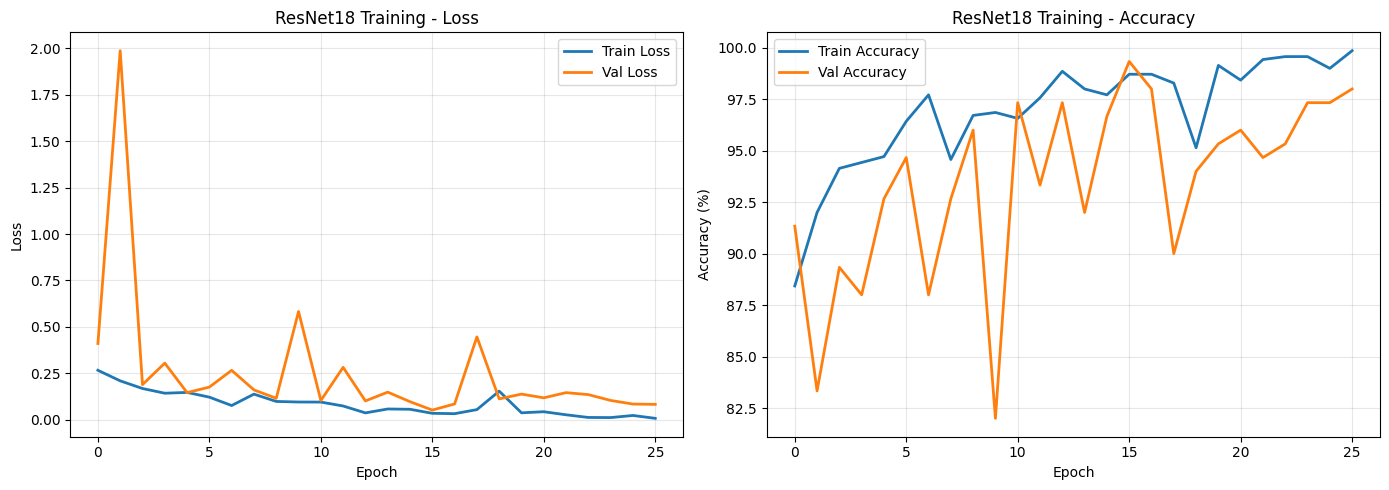

📊 Training Results:
   Best Val Accuracy: 99.33%
   Best Val Loss: 0.0516
   Total Epochs: 26
   Visualization saved: resnet18_training_history.png


In [11]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('ResNet18 Training - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('ResNet18 Training - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('F:\\TA1\\resnet18_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📊 Training Results:")
print(f"   Best Val Accuracy: {best_val_acc:.2f}%")
print(f"   Best Val Loss: {best_val_loss:.4f}")
print(f"   Total Epochs: {len(history['train_loss'])}")
print(f"   Visualization saved: resnet18_training_history.png")